1. Problem Understanding
Input variables (X):

Study_Hours_per_Day, Attendance_Percentage, Previous_Grade, Assignments_Completed, Sleep_Hours, Internet_Usage_Hours


Output variable (y):
Exam_Score

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/content/student_performance_dataset.csv")

load the data

In [4]:
df

,Study_Hours_per_Day,Attendance_Percentage,Previous_Grade,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Exam_Score
0,5.993428,88.892663,NaN,2.0,3.000000,3.258024,NaN
1,4.723471,100.000000,78.869505,0.0,4.338301,1.411031,57.476738
2,6.295377,54.021486,65.894456,2.0,5.761473,4.069592,68.543923
3,8.046060,83.444539,55.295948,5.0,4.485643,4.440208,68.622971
4,NaN,NaN,75.473350,7.0,5.628833,1.191357,45.966007
...,...,...,...,...,...,...,...
495,6.077820,70.783496,95.091393,7.0,4.406999,0.000000,71.232510
496,2.925508,100.000000,95.922554,10.0,3.138989,3.260942,65.701160
497,4.619323,NaN,83.125493,3.0,6.059305,1.441390,44.643598
498,3.248763,66.432315,80.360938,0.0,6.716892,3.024824,29.528327


Basic Data Check

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours_per_Day    475 non-null    float64
 1   Attendance_Percentage  475 non-null    float64
 2   Previous_Grade         475 non-null    float64
 3   Assignments_Completed  475 non-null    float64
 4   Sleep_Hours            475 non-null    float64
 5   Internet_Usage_Hours   475 non-null    float64
 6   Exam_Score             475 non-null    float64
dtypes: float64(7)
memory usage: 27.5 KB


gives a summary of the dataset and The dataset has 500 rows and 7 columns.
All columns are of type float64 (numeric values).
Each column has 475 non-null values, which means some data is missing.

In [6]:
df.shape

(500, 7)

give the number of rows and column present repectively

In [7]:
df.describe()

,Study_Hours_per_Day,Attendance_Percentage,Previous_Grade,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Exam_Score
count,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000
mean,5.184748,75.233763,66.831601,4.945263,6.599194,3.106057,55.230666
std,2.402849,14.085093,15.138726,3.114068,1.505748,1.526607,12.672220
min,0.000000,35.235453,21.556169,0.000000,3.000000,0.000000,23.630697
25%,3.645916,66.230357,56.264312,2.000000,5.483724,2.180379,46.839891
50%,5.135056,75.403288,66.883647,5.000000,6.698205,3.138811,55.017667
75%,6.372312,85.225441,76.905769,8.000000,7.629236,4.078755,63.268546
max,26.194647,100.000000,100.000000,10.000000,10.000000,7.890737,96.317533


statistical summary of all numerical columns  in which count give number of non missing value ,std give variance ,and min max give lowest and highest value

In [8]:
df.head()

,Study_Hours_per_Day,Attendance_Percentage,Previous_Grade,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Exam_Score
0,5.993428,88.892663,NaN,2.0,3.000000,3.258024,NaN
1,4.723471,100.000000,78.869505,0.0,4.338301,1.411031,57.476738
2,6.295377,54.021486,65.894456,2.0,5.761473,4.069592,68.543923
3,8.046060,83.444539,55.295948,5.0,4.485643,4.440208,68.622971
4,NaN,NaN,75.473350,7.0,5.628833,1.191357,45.966007


gives first 5 rows from dataset

In [9]:
df.tail()

,Study_Hours_per_Day,Attendance_Percentage,Previous_Grade,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Exam_Score
495,6.077820,70.783496,95.091393,7.0,4.406999,0.000000,71.232510
496,2.925508,100.000000,95.922554,10.0,3.138989,3.260942,65.701160
497,4.619323,NaN,83.125493,3.0,6.059305,1.441390,44.643598
498,3.248763,66.432315,80.360938,0.0,6.716892,3.024824,29.528327
499,6.703202,83.588742,73.887904,9.0,7.237213,2.471917,83.092717


gives last 5 rows

Delete columns with all unique values

In [11]:
for col in df.columns:
    if df[col].nunique() == len(df):
        df.drop(columns=[col], inplace=True)

This code removes columns with all unique values because they don’t contribute to model learning (like ID columns).

Handling Null Values

In [12]:
df.isnull().sum()

,0
Study_Hours_per_Day,25
Attendance_Percentage,25
Previous_Grade,25
Assignments_Completed,25
Sleep_Hours,25
Internet_Usage_Hours,25
Exam_Score,25


null value present

In [13]:
for col in df.columns:
    if df[col].dtype == "float64":
        df[col].fillna(df[col].mean(), inplace=True)
    elif df[col].dtype == "int64":
        df[col].fillna(df[col].median(), inplace=True)

This code handles missing values by replacing them with mean or median, ensuring the dataset is clean and ready for model training

In [14]:
df.isnull().sum()

,0
Study_Hours_per_Day,0
Attendance_Percentage,0
Previous_Grade,0
Assignments_Completed,0
Sleep_Hours,0
Internet_Usage_Hours,0
Exam_Score,0


now no null value is present

Check duplicates

In [16]:
df.duplicated().sum()

np.int64(0)

dataset has no duplicate records

split categorical and numerical value

In [18]:
categorical_columns = df.select_dtypes(include="object").columns
numerical_columns = df.select_dtypes(exclude="object").columns

we can apply appropriate preprocessing techniques to each type

Handling Error Values

In [19]:
df.replace(["?", "/", "unknown"], np.nan, inplace=True)

  invalid placeholder values into NaN

Outlier Handling (IQR Method)

In [20]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

removes outliers from numerical columns

univariate and bivariate analysis

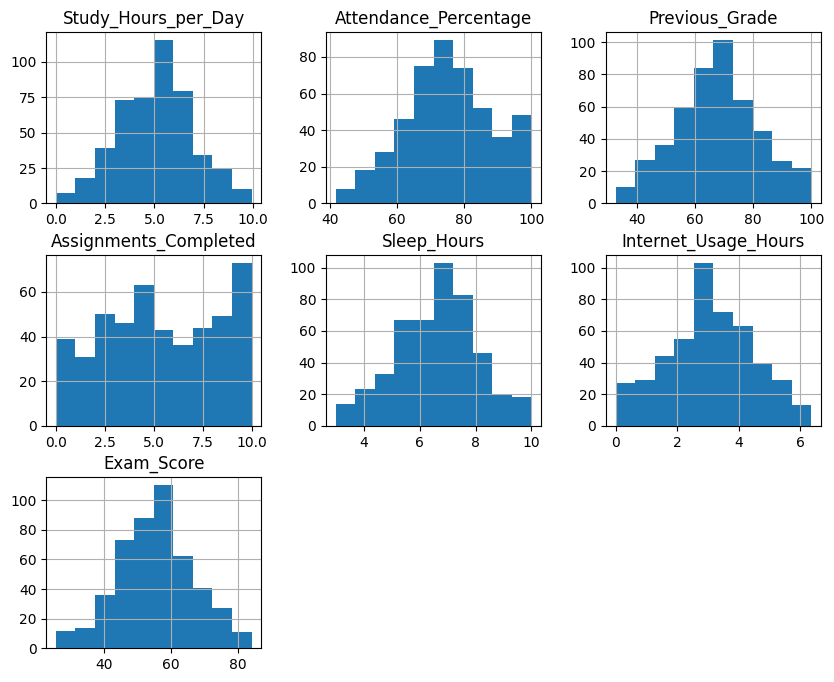

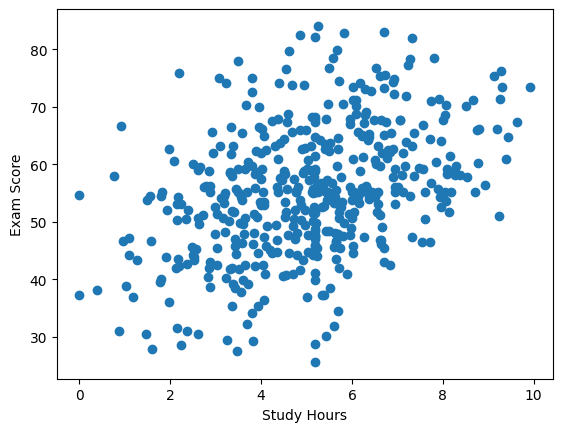

In [21]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

plt.scatter(df["Study_Hours_per_Day"], df["Exam_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

visualizes data distribution using histograms and shows the relationship between study hours and exam score using a scatter plot.

Divide dataset into X and y

In [22]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

separates features (input) and target (output) for model training.

exam_score is the target variable

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

splits the dataset into training and testing sets.

Initialize Model

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

imports and creates a Linear Regression model

In [25]:
model.fit(X_train, y_train)

LinearRegression()

step trains the model by learning the relationship between input features and exam scores

Model Evaluation (Regression)

In [26]:
y_pred = model.predict(X_test)

uses the trained model to predict exam scores for unseen test data.

Evaluation metrics

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 81.1290467905772
MAE: 7.291627204658088
R2 Score: 0.24016904260434324


These metrics show the model’s prediction error and accuracy, and here the low R² indicates the model performance is weak

improving model performance by using diffrent models

In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Decision Tree
modeld = DecisionTreeRegressor(random_state=42)
modeld.fit(X_train, y_train)
y_pred_d = modeld.predict(X_test)

print("Decision Tree Results")
print("MSE:", mean_squared_error(y_test, y_pred_d))
print("MAE:", mean_absolute_error(y_test, y_pred_d))
print("R2 Score:", r2_score(y_test, y_pred_d))


# Random Forest
modelr = RandomForestRegressor(n_estimators=100, random_state=42)
modelr.fit(X_train, y_train)
y_pred_r = modelr.predict(X_test)

print("\nRandom Forest Results")
print("MSE:", mean_squared_error(y_test, y_pred_r))
print("MAE:", mean_absolute_error(y_test, y_pred_r))
print("R2 Score:", r2_score(y_test, y_pred_r))

Decision Tree Results
MSE: 166.2234190444118
MAE: 10.558721925572486
R2 Score: -0.5567999949527851

Random Forest Results
MSE: 103.71253302340935
MAE: 8.126270063595996
R2 Score: 0.028658706362878816


both are weak models


In [31]:

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# ---------------- PCA APPLIED ---------------- #

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


# Decision Tree
modeld = DecisionTreeRegressor(random_state=42)
modeld.fit(X_train_pca, y_train)
y_pred_d = modeld.predict(X_test_pca)

print("\nDecision Tree with PCA")
print("MSE:", mean_squared_error(y_test, y_pred_d))
print("MAE:", mean_absolute_error(y_test, y_pred_d))
print("R2 Score:", r2_score(y_test, y_pred_d))


# Random Forest with GridSearchCV
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=5,
                    scoring="r2")

grid.fit(X_train_pca, y_train)

modelr = grid.best_estimator_
y_pred_r = modelr.predict(X_test_pca)

print("\nRandom Forest with PCA + GridSearchCV")
print("Best Params:", grid.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred_r))
print("MAE:", mean_absolute_error(y_test, y_pred_r))
print("R2 Score:", r2_score(y_test, y_pred_r))


Decision Tree with PCA
MSE: 181.58919052971748
MAE: 11.065731526338174
R2 Score: -0.7007113229009738

Random Forest with PCA + GridSearchCV
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
MSE: 113.22496480895224
MAE: 8.434443401488583
R2 Score: -0.06043195150504288


PCA made Decision Tree perform even worse Even after tuning, performance is not good

PCA and hyperparameter tuning were applied, but they did not improve performance, indicating the dataset may lack strong predictive features.

Dataset has weak relationships
Simple model works better than complex ones

new data check

In [32]:
new_data = pd.DataFrame({
    "Study_Hours_per_Day": [6],
    "Attendance_Percentage": [85],
    "Previous_Grade": [70],
    "Assignments_Completed": [8],
    "Sleep_Hours": [7],
    "Internet_Usage_Hours": [2]
})

In [33]:
prediction = model.predict(new_data)

print("Predicted Exam Score:", prediction[0])

Predicted Exam Score: 61.00057020388936
